# IMPORTANCIA DE FEATURES — VIDEO FINGER TAPPING MDS-UPDRS 3.4
## Análisis LDA + RandomForest — Comparación con sistema IMU

---
## CELDA 1 — Imports y configuración

In [1]:
"""
============================================================================
IMPORTS Y CONFIGURACIÓN GLOBAL
Centraliza rutas, paletas y parámetros del análisis de importancia.
============================================================================
"""

import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)


# ─────────────────────────────────────────────
# CONFIGURACIÓN — ajustar parámetros aquí
# ─────────────────────────────────────────────
class Config:
    DATASET_ID = "fis"
    RUTA_FEATURES = f"../output_files/{DATASET_ID}_classical_features.csv"
    RUTA_DIAGNOSTICO = f"../input_files/{DATASET_ID}_diagnostic.csv"
    RUTA_SALIDA = "../results_files/importancia_features/"

    # Rutas IMU para comparación dinámica
    RUTA_KW_IMU = (
        "../../imu_analysis/resultados_golpeteo_completo/tablas/kruskal_wallis.csv"
    )

    SCORE_COLORS = {
        0: "#2196F3",
        1: "#4CAF50",
        2: "#FF9800",
        3: "#F44336",
        4: "#9C27B0",
    }
    RANDOM_STATE = 12883823

    # Top features IMU para comparación (Fallback "quemado")
    IMU_TOP_FEATURES = {
        "cadencia": 0.7059,
        "iti_media": 0.6577,
        "iti_std": 0.6228,
        "jerk_rms": 0.5990,
        "compensacion_lateral": 0.5400,
        "jerk_rms_angular": 0.3325,
        "frecuencia": 0.2032,
    }

    # Mapeo features equivalentes IMU → Video
    EQUIVALENCIAS = {
        "cadencia": "FREQUENCY_mean",
        "iti_media": "ITI_MEAN",
        "iti_std": "ITI_STD",
        "jerk_rms": "JERK_RMS",
        "frecuencia": "FREQUENCY_mean",
        "regularidad_ritmica": "INTERVAL_CV",
        "amplitud_cv": "SMOOTHED_AMPLITUDE_std",
    }


os.makedirs(Config.RUTA_SALIDA, exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/figuras", exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/tablas", exist_ok=True)

print("✅ Configuración cargada")

✅ Configuración cargada


---
## CELDA 2 — Carga y preparación

In [2]:
"""
============================================================================
CARGA Y PREPARACIÓN DEL DATASET
============================================================================
"""

# Intentar cargar top features IMU dinámicamente
try:
    df_kw_imu = pd.read_csv(Config.RUTA_KW_IMU)
    # Tomar top 10 o las disponibles
    new_top = df_kw_imu.sort_values('eta2', ascending=False).head(10)
    Config.IMU_TOP_FEATURES = dict(zip(new_top['feature'], new_top['eta2']))
    print("★ Top features IMU actualizadas desde el workspace")
except FileNotFoundError:
    print("⚠️ No se encontró kruskal_wallis.csv de IMU, usando valores 'quemados'")

df_features = pd.read_csv(Config.RUTA_FEATURES)
if 'Unnamed: 0' in df_features.columns:
    df_features = df_features.rename(columns={'Unnamed: 0': 'ID'})
elif 'ID' not in df_features.columns:
    df_features = df_features.rename(columns={df_features.columns[0]: 'ID'})
df_features['ID'] = df_features['ID'].astype(str)

df_diag = pd.read_csv(Config.RUTA_DIAGNOSTICO, dtype={'ID': str})
df_diag['UPDRS'] = df_diag['UPDRS'].astype(int)
df_diag = df_diag.rename(columns={'UPDRS': 'score'})

df_merge = pd.merge(df_features, df_diag, on='ID', how='inner')
feature_cols = [c for c in df_merge.columns if c not in ['ID', 'score']]

X = df_merge[feature_cols].values
y = df_merge['score'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'✅ Dataset: {df_merge.shape[0]} muestras, {len(feature_cols)} features')
print('★ Distribución de scores:')
print(df_merge['score'].value_counts().sort_index().to_string())
print(f'★ N features: {len(feature_cols)}')

★ Top features IMU actualizadas desde el workspace
✅ Dataset: 220 muestras, 31 features
★ Distribución de scores:
score
0    68
1    96
2    33
3    23
★ N features: 31


---
## CELDA 3 — Importancia LDA

⚠️ Entrenamiento completo: solo interpretación, no evaluación.


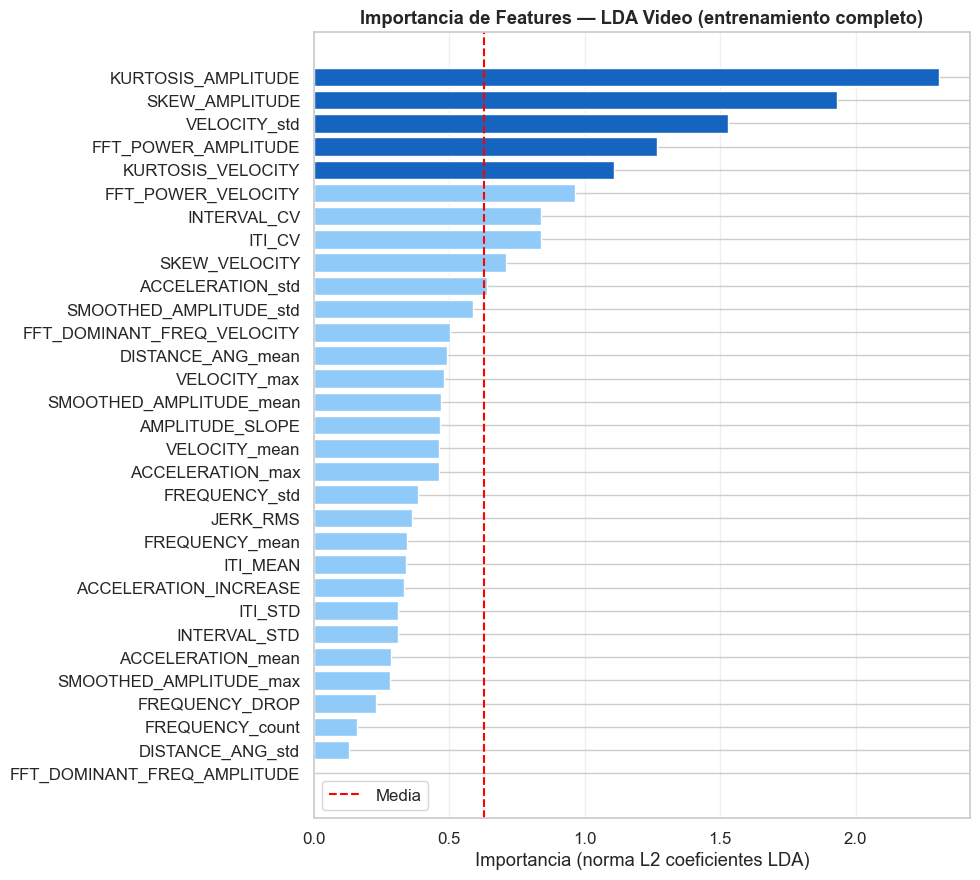

💾 Tabla LDA guardada
Top 10 — LDA
1. KURTOSIS_AMPLITUDE = 2.3078
2. SKEW_AMPLITUDE = 1.9307
3. VELOCITY_std = 1.5307
4. FFT_POWER_AMPLITUDE = 1.2665
5. KURTOSIS_VELOCITY = 1.1093
6. FFT_POWER_VELOCITY = 0.9635
7. INTERVAL_CV = 0.8380
8. ITI_CV = 0.8380
9. SKEW_VELOCITY = 0.7117
10. ACCELERATION_std = 0.6393


In [3]:
"""
============================================================================
IMPORTANCIA DE FEATURES — Coeficientes LDA (norma L2)
Entrenamiento con TODO el dataset — solo para interpretación,
no para evaluación. La evaluación honesta está en el LOO.
============================================================================
"""

print('⚠️ Entrenamiento completo: solo interpretación, no evaluación.')

lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda.fit(X_scaled, y)

importance_lda = np.linalg.norm(lda.coef_, axis=0)
df_lda = pd.DataFrame({'feature': feature_cols, 'importance': importance_lda})
df_lda = df_lda.sort_values('importance', ascending=False).reset_index(drop=True)

mean_imp = df_lda['importance'].mean()
colors = ['#1565C0' if i < 5 else '#90CAF9' for i in range(len(df_lda))]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(df_lda['feature'], df_lda['importance'], color=colors)
ax.axvline(mean_imp, color='red', linestyle='--', label='Media')
ax.set_xlabel('Importancia (norma L2 coeficientes LDA)')
ax.set_title('Importancia de Features — LDA Video (entrenamiento completo)', fontweight='bold')
ax.invert_yaxis()
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/importancia_lda_video.png", dpi=150, bbox_inches='tight')
plt.show()

df_lda.to_csv(f"{Config.RUTA_SALIDA}/tablas/importancia_lda_video.csv", index=False)
print('💾 Tabla LDA guardada')

print('Top 10 — LDA')
for i, row in df_lda.head(10).iterrows():
    print(f"{i + 1}. {row['feature']} = {row['importance']:.4f}")

---
## CELDA 4 — Importancia RandomForest

⚠️ Permutation importance puede tardar varios minutos...


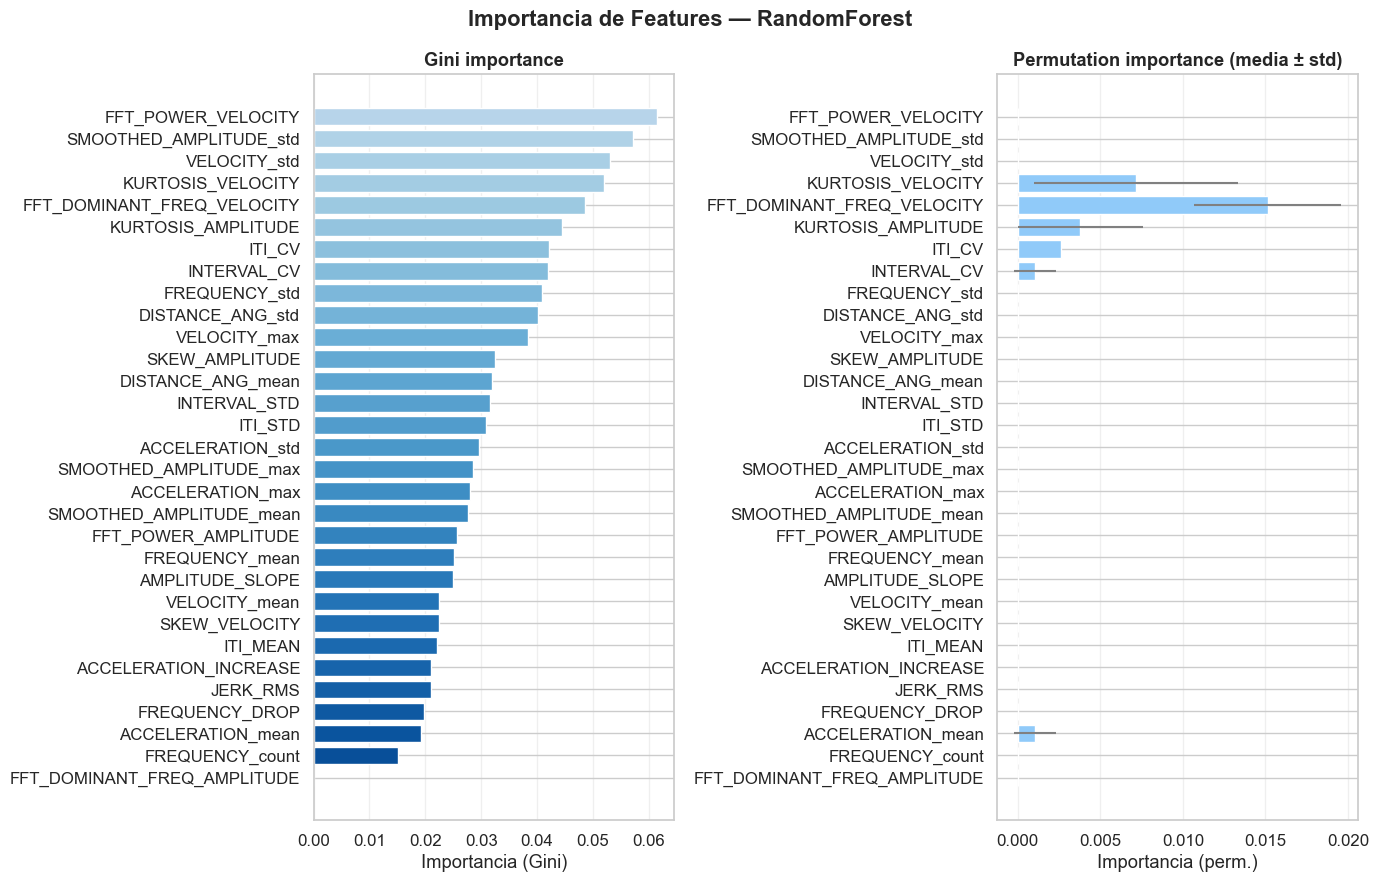

💾 Tablas RF guardadas
Nota: LDA captura separabilidad lineal; RF captura interacciones no lineales.


In [4]:
"""
============================================================================
IMPORTANCIA DE FEATURES — RandomForest feature_importances_
============================================================================
"""

rf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    class_weight='balanced',
    min_samples_leaf=1,
    min_samples_split=2,
    max_depth=None,
    random_state=Config.RANDOM_STATE
)
rf.fit(X_scaled, y)

gini_importance = rf.feature_importances_
df_rf = pd.DataFrame({'feature': feature_cols, 'importance': gini_importance})
df_rf = df_rf.sort_values('importance', ascending=False).reset_index(drop=True)

print('⚠️ Permutation importance puede tardar varios minutos...')
perm_result = permutation_importance(
    rf,
    X_scaled,
    y,
    n_repeats=10,
    random_state=Config.RANDOM_STATE,
    scoring='balanced_accuracy',
    n_jobs=-1
)

df_perm = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
})

order = df_rf['feature'].tolist()
df_perm = df_perm.set_index('feature').loc[order].reset_index()

colors_rf = plt.cm.Blues(np.linspace(0.3, 0.9, len(order)))

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
ax1, ax2 = axes

ax1.barh(order, df_rf['importance'], color=colors_rf)
ax1.set_title('Gini importance', fontweight='bold')
ax1.set_xlabel('Importancia (Gini)')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

ax2.barh(
    order,
    df_perm['importance_mean'],
    xerr=df_perm['importance_std'],
    color='#90CAF9',
    ecolor='gray'
 )
ax2.set_title('Permutation importance (media ± std)', fontweight='bold')
ax2.set_xlabel('Importancia (perm.)')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

fig.suptitle('Importancia de Features — RandomForest', fontweight='bold')
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/importancia_rf_video.png", dpi=150, bbox_inches='tight')
plt.show()

df_rf.to_csv(f"{Config.RUTA_SALIDA}/tablas/importancia_rf_video.csv", index=False)
df_perm.to_csv(f"{Config.RUTA_SALIDA}/tablas/importancia_rf_permutation_video.csv", index=False)
print('💾 Tablas RF guardadas')

print('Nota: LDA captura separabilidad lineal; RF captura interacciones no lineales.')

---
## CELDA 5 — Comparación IMU vs Video

⚠️ Sin equivalencia para IMU: compensacion_lateral
⚠️ Sin equivalencia para IMU: jerk_rms_angular
⚠️ Sin equivalencia para IMU: velocidad_pico_media
⚠️ Sin equivalencia para IMU: rms_acc_lateral
⚠️ Sin equivalencia para IMU: decremento_pct


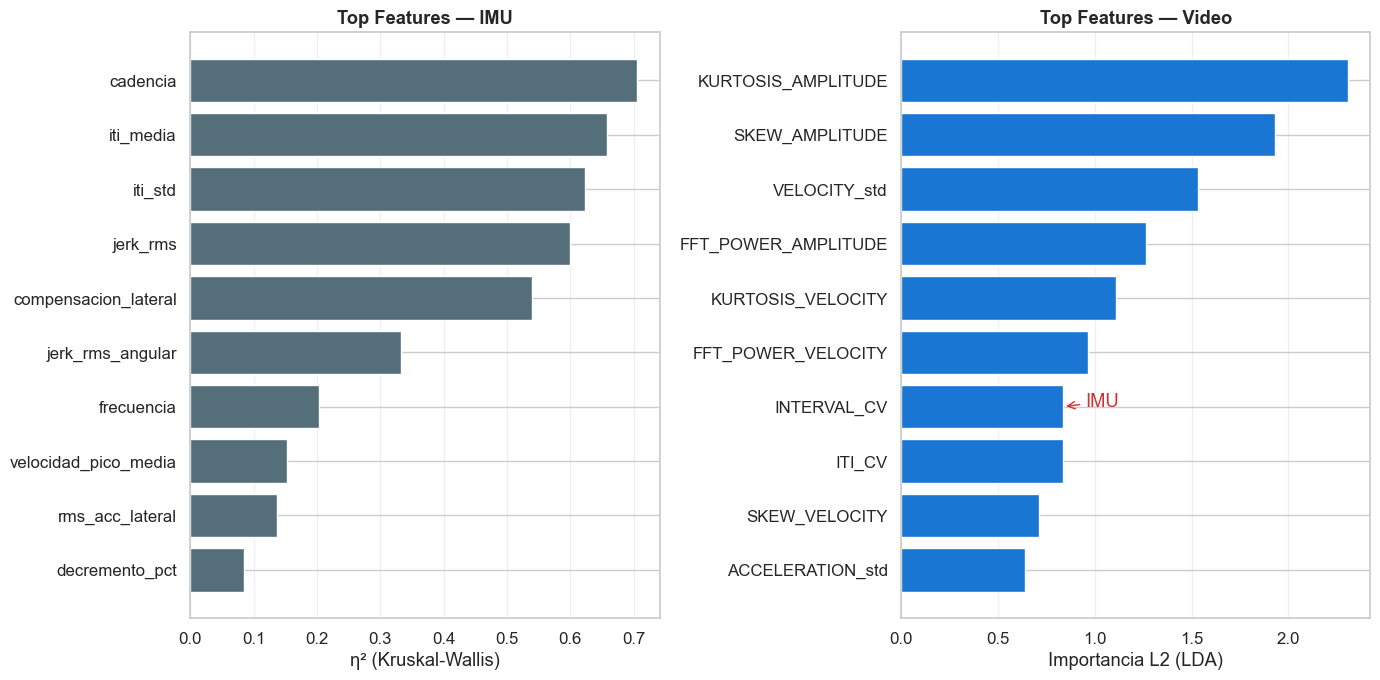

¿ITI domina en video como en IMU?: No
Features video sin equivalente IMU en top 10:
KURTOSIS_AMPLITUDE, SKEW_AMPLITUDE, VELOCITY_std, FFT_POWER_AMPLITUDE, KURTOSIS_VELOCITY, FFT_POWER_VELOCITY, ITI_CV, SKEW_VELOCITY, ACCELERATION_std
Conclusión: hay transferencia parcial de conocimiento entre IMU y video.


In [5]:
"""
============================================================================
COMPARACIÓN — Top features IMU vs Top features Video
============================================================================
"""

def _get_importance(df, feature, col):
    if feature is None:
        return np.nan
    if df is None or df.empty:
        return np.nan
    match = df[df['feature'] == feature]
    if match.empty:
        print(f"⚠️ Feature no encontrada: {feature}")
        return np.nan
    return float(match.iloc[0][col])

imu_sorted = sorted(Config.IMU_TOP_FEATURES.items(), key=lambda x: x[1], reverse=True)
rows = []
for rank, (imu_feat, eta2) in enumerate(imu_sorted, start=1):
    video_feat = Config.EQUIVALENCIAS.get(imu_feat)
    if video_feat is None:
        print(f"⚠️ Sin equivalencia para IMU: {imu_feat}")
    lda_imp = _get_importance(df_lda, video_feat, 'importance')
    rf_imp = _get_importance(df_rf, video_feat, 'importance')
    rows.append({
        'Rank IMU': rank,
        'Feature IMU': imu_feat,
        'η² IMU': eta2,
        'Feature Video equivalente': video_feat,
        'Importancia LDA Video': lda_imp,
        'Importancia RF Video': rf_imp
    })

df_comp = pd.DataFrame(rows)
df_comp = df_comp.sort_values('η² IMU', ascending=False)
df_comp.to_csv(f"{Config.RUTA_SALIDA}/tablas/comparacion_importancia.csv", index=False)

imu_top10 = imu_sorted[:10]
imu_features = [f for f, _ in imu_top10]
imu_vals = [v for _, v in imu_top10]

video_top10 = df_lda.head(10)
video_features = video_top10['feature'].tolist()
video_vals = video_top10['importance'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

y1 = np.arange(len(imu_features))
ax1.barh(y1, imu_vals, color='#546E7A')
ax1.set_yticks(y1)
ax1.set_yticklabels(imu_features)
ax1.set_xlabel('η² (Kruskal-Wallis)')
ax1.set_title('Top Features — IMU', fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

y2 = np.arange(len(video_features))
ax2.barh(y2, video_vals, color='#1976D2')
ax2.set_yticks(y2)
ax2.set_yticklabels(video_features)
ax2.set_xlabel('Importancia L2 (LDA)')
ax2.set_title('Top Features — Video', fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

equiv_values = set(Config.EQUIVALENCIAS.values())
x_max = max(video_vals) if len(video_vals) else 1.0
for idx, feat in enumerate(video_features):
    if feat in equiv_values:
        ax2.annotate(
            'IMU',
            xy=(video_vals[idx], idx),
            xytext=(min(video_vals[idx] + 0.05 * x_max, x_max), idx),
            arrowprops={'arrowstyle': '->', 'color': '#D32F2F'},
            color='#D32F2F',
        )

plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/comparacion_importancia_imu_video.png", dpi=150, bbox_inches='tight')
plt.show()

iti_in_top = any(f in video_features for f in ['ITI_MEAN', 'ITI_STD'])
print(f"¿ITI domina en video como en IMU?: {'Sí' if iti_in_top else 'No'}")

sin_equivalencia = [f for f in video_features if f not in equiv_values]
if sin_equivalencia:
    print('Features video sin equivalente IMU en top 10:')
    print(', '.join(sin_equivalencia))
else:
    print('Todas las features top 10 de video tienen equivalente IMU.')

overlap = [f for f in video_features if f in equiv_values]
if overlap:
    print('Conclusión: hay transferencia parcial de conocimiento entre IMU y video.')
else:
    print('Conclusión: el ranking de video difiere del IMU; poca transferibilidad directa.')

---
## CELDA 6 — Exportación final

In [6]:
"""
============================================================================
EXPORTACIÓN FINAL
============================================================================
"""

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
excel_path = f"{Config.RUTA_SALIDA}/tablas/importancia_features_{timestamp}.xlsx"

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_lda.to_excel(writer, sheet_name='lda_video', index=False)
    df_rf.to_excel(writer, sheet_name='rf_gini', index=False)
    df_perm.to_excel(writer, sheet_name='rf_permutation', index=False)
    df_comp.to_excel(writer, sheet_name='comparacion_imu_video', index=False)

print(f"💾 Importancia features exportada: {excel_path}")

top3_lda = df_lda.head(3)['feature'].tolist()
top3_rf = df_rf.head(3)['feature'].tolist()
imu_equiv = set(Config.EQUIVALENCIAS.values())

print(f"Top 3 LDA: {', '.join(top3_lda)}")
print(f"Top 3 RF: {', '.join(top3_rf)}")

coinciden_imu = [f for f in top3_lda if f in imu_equiv]
if coinciden_imu:
    print('Coinciden con IMU (equivalencias): ' + ', '.join(coinciden_imu))
else:
    print('No hay coincidencias directas con top IMU en el top 3 LDA.')

💾 Importancia features exportada: ../results_files/importancia_features//tablas/importancia_features_20260510_192348.xlsx
Top 3 LDA: KURTOSIS_AMPLITUDE, SKEW_AMPLITUDE, VELOCITY_std
Top 3 RF: FFT_POWER_VELOCITY, SMOOTHED_AMPLITUDE_std, VELOCITY_std
No hay coincidencias directas con top IMU en el top 3 LDA.
